In [12]:
%load_ext autoreload
%autoreload 2
import sys

import matplotlib.pyplot as plt
from astropy.table import Table
import numpy as np
sys.path.append('../target_selection/')
import lbg
sys.path.append('../')
from conversion import conv_COSMOS_XMM

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
data_path = '/global/cfs/cdirs/desi/users/cpayerne/data_WP221_Target_selection/photometric_catalogs/'
catalog = Table.read(data_path + 'COSMOS_11bands-SExtractor-Lephare.fits')
mag_depth = [27,27,26.7,26.5,26] #ugriz

In [15]:
conv = conv_COSMOS_XMM

In [16]:
def refined_selection_u(tab, conv):
    
    mask  = tab[conv['u_err']] > 0
    mask *= tab[conv['g_err']] > 0
    mask *= tab[conv['r_err']] > 0

    mask *= tab[conv['u_err']] < 1
    mask *= tab[conv['g_err']] < 1
    mask *= tab[conv['r_err']] < 1

    mask *= abs(tab[conv['u']] - tab[conv['g']])  < 10
    mask *= abs(tab[conv['g']] - tab[conv['r']])  < 10
    #mask *= abs(tab[conv['u']] - tab[conv['r']])  < 10
    return mask

def refined_selection_g(tab, conv):
    
    mask = tab[conv['g_err']] > 0
    mask *= tab[conv['r_err']] > 0
    mask *= tab[conv['i_err']] > 0

    mask *= tab[conv['g_err']] < 1
    mask *= tab[conv['r_err']] < 1
    mask *= tab[conv['i_err']] < 1

    mask *= abs(tab[conv['g']] - tab[conv['r']])  < 10
    mask *= abs(tab[conv['r']] - tab[conv['i']])  < 10

    return mask

def refined_selection_r(tab, conv):

    mask = tab[conv['r_err']] > 0
    mask *= tab[conv['i_err']] > 0
    mask *= tab[conv['z_err']] > 0

    mask *= tab[conv['r_err']] > 0
    mask *= tab[conv['i_err']] < 1
    mask *= tab[conv['z_err']] < 1

    return mask

In [81]:
mask_plot = refined_selection_u(catalog, conv)
cat_to_plot = catalog[mask_plot]
cat_to_plot = cat_to_plot[(cat_to_plot['ZPHOT'] > 0)*(cat_to_plot['r'] < 24.5)*(cat_to_plot['r'] > 22)]

In [83]:
def Christophe_highz_option1(tab, conv):
    #(u_g>0.0)   & (u_g > 1.5*(g_r-0.8) +2.0)  & (g_r>0.0) & (g_r<0.8)
    mask = (tab[conv['u']] - tab[conv['g']] > 0)
    mask *= (tab[conv['g']] - tab[conv['r']] > 0)
    mask *= (tab[conv['g']] - tab[conv['r']] <0.8)
    mask *= tab[conv['u']] - tab[conv['g']] > 1.5*(tab[conv['g']] - tab[conv['r']] - 0.8) + 2.0
    return mask
sel =  Christophe_highz_option1(cat_to_plot, conv)

(array([432.,  27.,  45.,  13.,  24.,   6.,  48.,  24.,  13.,   7.,  84.,
         46., 169., 816., 877., 223.,   4.,   1.,   1.]),
 array([0.        , 0.21052632, 0.42105263, 0.63157895, 0.84210526,
        1.05263158, 1.26315789, 1.47368421, 1.68421053, 1.89473684,
        2.10526316, 2.31578947, 2.52631579, 2.73684211, 2.94736842,
        3.15789474, 3.36842105, 3.57894737, 3.78947368, 4.        ]),
 <BarContainer object of 19 artists>)

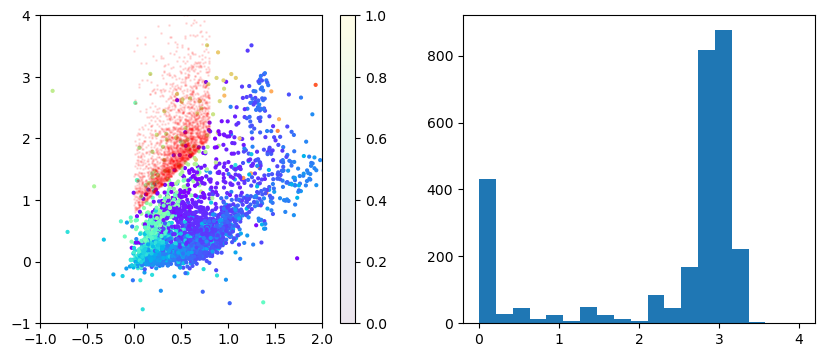

In [84]:
plt.figure(figsize=(10,4))
plt.subplot(121)
n = np.random.choice(np.arange(len(cat_to_plot)), 3000, replace=False)
plt.scatter(cat_to_plot[n]['g'] - cat_to_plot[n]['r'], cat_to_plot[n]['u'] - cat_to_plot[n]['g'], vmin=0, c=cat_to_plot[n]['ZPHOT'],s=4, cmap='rainbow')
plt.scatter(cat_to_plot[sel]['g'] - cat_to_plot[sel]['r'], cat_to_plot[sel]['u'] - cat_to_plot[sel]['g'], c='r', s=1, alpha=0.1, )
plt.colorbar()
plt.xlim(-1, 2)
plt.ylim(-1, 4)
plt.subplot(122)
plt.hist(cat_to_plot[sel]['ZPHOT'], bins=np.linspace(0, 4, 20))

Text(0.5, 0, 'ZPHOT')

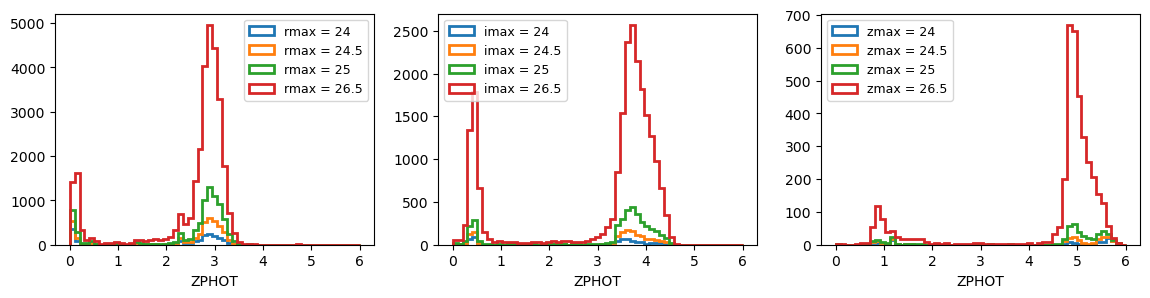

In [86]:
plt.figure(figsize=(14, 3))
plt.subplot(131)
mask_udrop = LBG_SELECTION(catalog, conv, name='COSMOS_TMG_U_normagcut') * refined_selection_u(catalog, conv)
#mask_udrop = Christophe_highz_option1(catalog, conv) * refined_selection_u(catalog, conv)
z_edges = np.linspace(0, 6, 60)
z_mid = np.array([(z_edges[i] + z_edges[i+1])/2 for i in range(len(z_edges)-1)])
rmax_list = [24, 24.5, 25, 26.5]
rmax_name = ['24', '24_5', '25', '26_5']
rmin = 22.5
for i, rmax in enumerate(rmax_list):
    mask_r = (catalog['r'] < rmax)*(catalog['r'] > rmin)
    n_udrop_, b, _ = plt.hist(catalog['ZPHOT'][mask_udrop * mask_r], 
                             bins=z_edges, histtype='step', linewidth=2, label = f'rmax = {rmax_list[i]}')
plt.legend(fontsize=9)
plt.xlabel('ZPHOT')

plt.subplot(132)
mask_gdrop = lbg.LBG_SELECTION(catalog, conv, name='COSMOS_G_noimagcut') * refined_selection_g(catalog, conv)
imax_list = [24, 24.5, 25, 26.5]
imax_name = ['24', '24_5', '25', '26_5']
imin = 22.5
for i, imax in enumerate(imax_list):
    mask_i = (catalog['i'] < imax)*(catalog['i'] > imin)
    n_gdrop_, b, _ = plt.hist(catalog['ZPHOT'][mask_gdrop * mask_i], 
                             bins=z_edges, histtype='step', linewidth=2, label = f'imax = {imax_list[i]}')
plt.legend(fontsize=9)
plt.xlabel('ZPHOT')
plt.subplot(133)
mask_rdrop = lbg.LBG_SELECTION(catalog, conv, name='COSMOS_R_nozmagcut') * refined_selection_r(catalog, conv)
zmax_list = [24, 24.5, 25, 26.5]
zmax_name = ['24', '24_5', '25', '26_5']
zmin = 22.5
for i, zmax in enumerate(zmax_list):
    mask_z = (catalog['z'] < zmax)*(catalog['z'] > zmin)
    n_rdrop_, b, _ = plt.hist(catalog['ZPHOT'][mask_rdrop * mask_z], 
                             bins=z_edges, histtype='step', linewidth=2, label = f'zmax = {zmax_list[i]}')
plt.legend()
plt.xlabel('ZPHOT')
plt.legend(fontsize=9)
plt.xlabel('ZPHOT')

In [7]:
path_tracer_cat = '/global/cfs/cdirs/desi/users/cpayerne/data_WP221_Target_selection/photometric_tracer_catalogs/'
catalog_lbg_udropout = catalog[mask_udrop * (catalog['r'] < 25.5)*(catalog['r'] > 22.5)]
catalog_lbg_udropout.write(path_tracer_cat + 'cosmos_lbg_udropout_rmax25_5.fits', overwrite=True)

In [8]:
catalog_lbg_gdropout = catalog[mask_gdrop * (catalog['i'] < 25.5)*(catalog['i'] > 22.5)]
catalog_lbg_gdropout.write(path_tracer_cat + 'cosmos_lbg_gdropout_imax25_5.fits', overwrite=True)

In [9]:
catalog_lbg_rdropout = catalog[mask_rdrop * (catalog['z'] < 25.5)*(catalog['z'] > 22.5)]
catalog_lbg_rdropout.write(path_tracer_cat + 'cosmos_lbg_rdropout_zmax25_5.fits', overwrite=True)